## Introduction

## 0.1 - Imports
The code block below represents where all imports for the noteboook are initilised. 

In [132]:
# Import Library
import pandas as pd

# Sklearn Imports:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Data Display Imports
import matplotlib.pyplot as plt

## 0.2 Import Datasets
This code block represents where all the datasets that will be worked on throughout this notebook are imported and initilised. 'customer_features' is copied in order to preserve the original data, whilst ammendments and changes are implemented. 

In [133]:
# Import the scaled dataset
customer_features_scaled = pd.read_csv('../0_Data/processed_data/customer_features_scaled.csv')
customer_features = pd.read_csv('../0_Data/processed_data/customer_features.csv')

# Create a copy of the dataset we will be working on: 
scaled_df = customer_features_scaled.copy()

## 1.0 Pre-pipeline Steps
At this point scaling and preprocessing has been completely finished. However there are still a few steps we need to confirm before initlising the pipeline. The first is removing customer_id from the dataset but keeping to hand for later. This is done because customer_id does not provide any benifit for the models in terms of unveiling consumer behaviour and secondly, it is the only column that did not have StandardScalar applied to it - as we did not want to change the actual customer_id's.

In [134]:
# pull customer_id into its own dataset; 
customer_ids = scaled_df['customer_id']

# Drop customer_id from the working dataset: 
scaled_df = scaled_df.drop(columns=['customer_id'])

# Implement a function that checks if customer_id was successfully removed.
def customer_features_removal(df):
    if scaled_df.columns.all() == 'customer_id':
        print("'customer_id' still present")
    else: print("'customer_id' successfully removed")

# Call the customer_features_removal function using scaled_df. 
customer_features_removal(scaled_df)

'customer_id' successfully removed


## 2.0 - Machine Learning Pipeline Implementation

### 2.1 - KMeans Algorithm
Before implementing k-means algorithms, we need to identify what value of 'k' is most suitable for our model. This will be done using elbow and silhoutte approaches. 

**'k' Value indentification methodology:**
The elbow method used 'inertia' as a way of measuring how closely points are plotted to each other. The logic is, as you add more points (increasing k) inertia decreased where eventually it hits 0. The key with this test is not identifying the lowest point but where the elbow is situated (displayed visually within a graph). The elbow represents the point at which increasing values of k stops providing value and start diluting clusters. Using the elbow method should result in a plot that decreases sharply at first and then levels off. It is at this point of the leveling off (the elbow) where the value of 'k' is the best choice for the data. 

Sometimes, the result of the elbow method does not produce a clear and distinct point of leveling off. This is why it is useful to deploy a second method of identifying the most suitable value of 'k' - using silhouete score. Silhouette score is reponsible for measuring the quulity of the clusters that are created. The silhouette score measures two things. The first is the how close each point is to the other points within its own cluster as well as how far away it is from points in the next closest cluster. The idea is, if a point sits close to other points within its own cluster and far away from other clusters, it is given a high score. However, in the opposite case, if a point is sitting closer to another cluster, the score is lower. Scores are issued in the range of -1 to 1. By combining the average silhouette score for each point the result should indicate how well defined each cluster is - value of k with the highest silhouette score is usually the a solid indicator of the best value of 'k'. 

### Determining K
KMeans is a clustering algorithim that is distance based. The idea behind its implementation within this context is to uncover clusters within the data. This is powerful as patterns that arent necessirily present then looking at raw data is uncovered during visual segments.

Before implementing the algorithm, the value of k needs to be determined. In this context K represents how many different groups or segments the algorithm will produce. It is important to get 'k' for multiple reasons: 

- **K to low**: If the value of k is too low, unique and distinct bevahours are often missed where different groups are missed together - removing the point of the algorithm entirely. For example, if k = 2 then our entire dataset would be split into two segements and with the range of features we have in the dataset, two segements is not enough to uncover any meaningful behaviours

- **k to high**: On the other hand if k is too high clusters fracture into indisgusiable segemnts that do not represent groupings of behaviour. 

- **Getting k correct**: Getting k correct represents the point where clusters represent meaningful and insightful behvioural patterns, which can be usd to uncover patterns within the data that would otherwise been missed. This is why finding the best value of 'k' is important. Below the first steps of identifying 'k' will be made. Starting off with Sihouette score and the elbow method. 

In order to find out what the value of 'k' is to ensure the KMeans algorithm is impplemented efficiently a two-step visulisation will be used. This is done using the elbow method to reveal what value of 'k' ensures KMeans works best and a second method that reinforces whether this value of 'k' is sound in principle - silhouette score. 

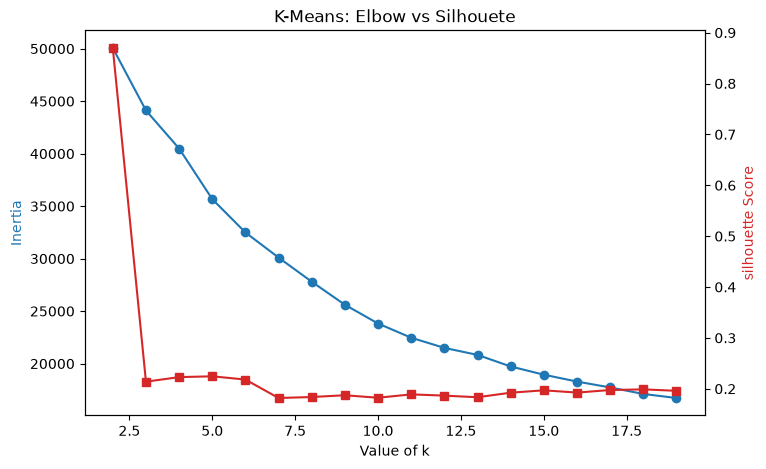

In [135]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested (2 through 10 inclusive)
k_range = range(2, 20)

# Initilise for each loop:
#
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    # random_state is a fixed value to ensure reproduceable results. 
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(scaled_df)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(scaled_df, labels))

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouete_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Title the plot:
plt.title('K-Means: Elbow vs Silhouete')

# Display the visulisation:
plt.show()

**Results**
As stipulated before we are looking for 2 particular behaviours. Firstly, with inertia (blue line) the visulisation we are looking for is the 'elbow' or the point at which a steep decline levels of.  The second, silhouette score is expected to peak at some point on the line indicating cleanly seperated points. In this case, both of these behaviours are not present - Inertia has no elbow and silhouette score has no defining peak. This is an indication that there is a segment of points within the data that is interfeering with both of these measurements. A low sihouette score, can be attributed to mutiple points that are pulled apart from others. In this case, a likely cause of this is the wholesale transactions that were left in during preprocessing. IN order to confirm this further investigation; specifically on  is needed.  

To start building a picture of what is effecting the results, a describe() filtering to display only min and max values will be displayed below. This aims to provide an insight into range between the smallest and largest values in each feature - if the range is large, that StandardScalar scaled alongside out outliers and their values are now causeing issues. 

In [136]:
scaled_df.describe().loc[['min', 'max']]

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
min,-2.036680,-68.430152,-0.410267,-0.326596,-0.676258,-0.690148,-2.483556,-1.369769,-1.398262,-0.636705
max,41.527424,10.465678,31.460162,42.868300,4.668382,21.270907,3.292813,1.853239,10.452141,1.570587


**Min & Max Descibe Evaluation**
As previously mentioned, StandardScalar has been deployed on te data within the preprocessing steps. When implemented on data that contains no outliers, StandardScalar produces values that all sit within a fairly tight radius. Displaying the minimum and maximum values above shows that there are cases where values do not sit within a tight range. For example in 'total_spend' we see that there is at least one case where a customer is -2 standard devisations from the average opposed to the maximum of +40 standard deviations. This is evidence that the extreme outliers are distorting clusters.  

This issues presents a choice. Wholesale transactions can be removed completely or moved to their own dataset. As mentioned in the preprocessing steps, there are multiple instances of wholesale transactions happening repeatidly, representing a genuiene business sgement. Rather than removing this data completely, it is important to retain it and work on these transactions within their own dataset. The first step in doing this is to identify a point in which transactions stop being classed as retail customers and are moved to wholesale transactions status. 

Rather than drawing a specific value (like a certin total_spend or quantity amount) it is better to visually inspect the spread of transactional values - strting with 'total_spend' 

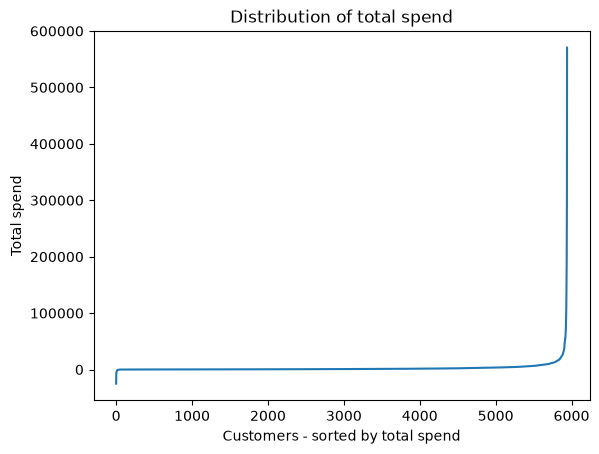

In [137]:
# Create a variable using the unscaled customer_features - grouped on 'customer_id' and 'total_spend':
transaction_spend_split = customer_features.groupby('customer_id')['total_spend'].sum().sort_values()

# Initilise a plot to display the results:
# Set figure size:
plt.Figure(figsize = (8, 5))
# Plot the values stored in the variable initilised above:
plt.plot(transaction_spend_split.values)
# X-label: Where each customer sits on an ordered total_spend list:
plt.xlabel('Customers - sorted by total spend')
# Y-label: Total Spend amount:
plt.ylabel('Total spend')
# PLot title:
plt.title('Distribution of total spend')
# Display the plot:
plt.show()

**Plot Evaluation**
The plot above confirms the above claims, that there is a very small number of observations with extreme values - specifically total_spend. Now the curve has been identified, we can move our investigation closer to the curve which occurs somewhere between the 5000th and 6000th customer. The next step is to produce another plot, this time focusing on only the customers between the 5500 and 6000 range:

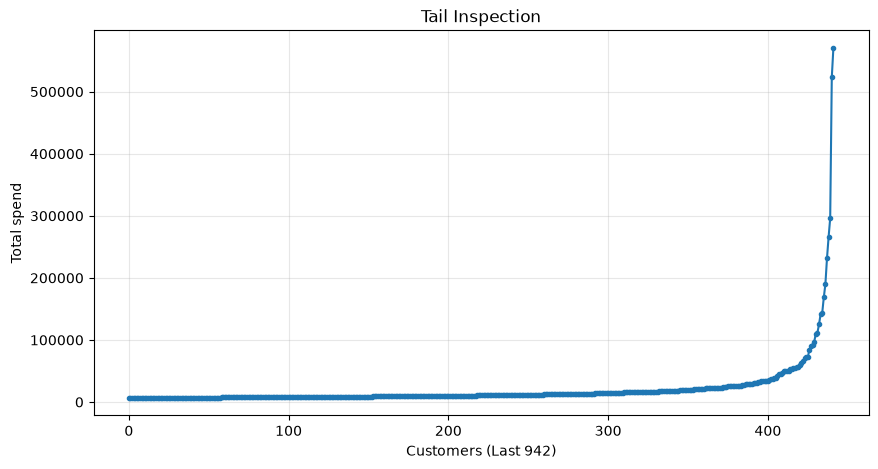

In [138]:
# Initilise another variable focusing on the top 442 Customers:
tail_inspection = transaction_spend_split[5500 : 5942].reset_index(drop = True)

# Set figure size:
plt.figure(figsize = (10, 5))
#
plt.plot(tail_inspection.index, tail_inspection.values, marker = 'o', markersize = 3)
#
plt.xlabel('Customers (Last 942)')
#
plt.ylabel('Total spend')
# Set plot title
plt.title('Tail Inspection')
#
plt.grid(True, alpha = 0.3)
# Display the plot
plt.show()

**Plot Analysis**
Looking at the last ~500 customers we can see that it is around he last 42 customers (~ the 400 mark) where transactions change exponentially. This allows a line to be drawn at this point. However, in an effort to be thourough a final inspection should be carried out. Using total_spend alone is useful in identifying the general behaviour of values, but it does not provide a complete picture. In order to draw a sensible conclusion a final step integrating 'total_item_count' should be used. The idea behind this this final check is to catch any valuable customers that by high-costing products. In this case 'total_spend_' alone runs the risk of categorising a loyal repeat customer in with wholesale transactions. Furthermore, it is very rare that wholesale transacitons will have low spend and quantity amounts, as such is the nature of wholesale transacitions.

To implement this

In [142]:
# Inspect the customer profile for cust: 5850
cust_by_spend = customer_features.sort_values('total_spend').reset_index(drop=True)
# Pull the 5850th customer: 
cust_5850 = cust_by_spend.iloc[5050]
# Print customer observation: 
print(cust_5850)

customer_id          16748.000000
total_spend           3632.290000
atv                     21.881265
total_visits            15.000000
total_item_count      2115.000000
cancellation_rate        0.066667
unique_products         55.000000
time_of_day             10.000000
day_of_week              2.000000
discount_rate            0.120482
loyalty_member           0.000000
Name: 5050, dtype: float64
